In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
# Преобразуем "сырой" датафрейм
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result

In [215]:
data = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt')
df = good_dataframe(data, '1h')
df

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 10:00:00,SBRF,1h,2301.0,2380.0,2265.0,2361.0,7797
1,2009-01-11 11:00:00,SBRF,1h,2366.0,2369.0,2324.0,2346.0,5669
2,2009-01-11 12:00:00,SBRF,1h,2346.0,2354.0,2328.0,2339.0,2264
3,2009-01-11 13:00:00,SBRF,1h,2335.0,2346.0,2330.0,2338.0,876
4,2009-01-11 14:00:00,SBRF,1h,2339.0,2342.0,2333.0,2334.0,860
...,...,...,...,...,...,...,...,...
61562,2026-02-28 14:00:00,SBRF,1h,31693.0,31705.0,31672.0,31684.0,575
61563,2026-02-28 15:00:00,SBRF,1h,31675.0,31701.0,31659.0,31699.0,644
61564,2026-02-28 16:00:00,SBRF,1h,31687.0,31703.0,31664.0,31700.0,338
61565,2026-02-28 17:00:00,SBRF,1h,31700.0,31722.0,31670.0,31693.0,1046


In [224]:
def SMA_function(data, N_F=20, N_S=150):
    data = data.copy()
    data = data.reset_index(drop=True)
    data[f'SMA_{N_F}'] = np.round(data['close'].rolling(window=N_F).mean(), 2)
    data[f'SMA_{N_S}'] = np.round(data['close'].rolling(window=N_S).mean(), 2)
    SMA_F_N = data[f'SMA_{N_F}']
    SMA_S_N = data[f'SMA_{N_S}']
    SMA_F_N_1 = data[f'SMA_{N_F}'].shift(1)
    SMA_S_N_1= data[f'SMA_{N_S}'].shift(1)
    # Сигнал 
    condition_buy = ((SMA_F_N_1 < SMA_S_N_1) & (SMA_F_N > SMA_S_N))
    condition_sell = ((SMA_F_N_1 > SMA_S_N_1) & (SMA_F_N < SMA_S_N))
    data[f'signal'] = 0
    data.loc[condition_buy, f'signal'] = 1
    data.loc[condition_sell, f'signal'] = -1
    
    # Делаем датафрейм четным
    signal_index = data[data[f'signal'] != 0].index
    first_index = signal_index[0]
    last_index = signal_index[-1]
    
    if data.loc[first_index, f'signal'] == -1:
        data.loc[first_index, f'signal'] = 0
    if data.loc[last_index, f'signal'] == 1:
        data.loc[last_index, f'signal'] = 0
        

    # Цена покупки и продажи
    data[f'possition'] = 0
    data.loc[data[f'signal'] == 1, f'possition'] = data['close']
    data.loc[data[f'signal'] == -1, f'possition'] = data['close']
    
 
    # Считаем результаты
    result_strategy = data[data[f'signal'] != 0]
    entry_price = result_strategy[f'possition'].iloc[::2].values
    exit_price = result_strategy[f'possition'].iloc[1::2].values
    commission = entry_price * 0.0002 + exit_price * 0.0002
    fin_res = pd.Series(np.round(((exit_price - entry_price - commission) / entry_price), 4), 
                        index=result_strategy[result_strategy['signal'] == 1]['time'])
    
    data.dropna(inplace=True)
    return data, fin_res
res, fin = SMA_function(df)


In [231]:
fin

time
2009-02-09 20:00:00   -0.0792
2009-03-04 12:00:00    0.2727
2009-04-03 18:00:00    0.1259
2009-04-23 22:00:00   -0.0468
2009-04-30 21:00:00    0.7714
                        ...  
2025-12-05 22:00:00   -0.0144
2025-12-17 10:00:00   -0.0230
2026-01-16 18:00:00   -0.0005
2026-01-29 20:00:00   -0.0056
2026-02-11 17:00:00    0.0219
Length: 289, dtype: float64

In [268]:
def statistics(result):
    win_rate = np.round((result > 0).mean(), 2) * 100
    mean_deal = np.round(np.mean(result) * 100, 2)
    count_profit = np.sum((result > 0))
    count_loss = np.sum((result < 0))
    median_deal = np.round(np.median(result) * 100, 2)
    
    # Доля сделок
    result_100 = result * 100
    bins = [0, 1, 2, 3, 5, 10, 20, 50]
    labels = ['0-1%', '1-2%', '2-3%', '3-5%', '5-10%', '10-20%', '20-50%']
    fin_binned = pd.cut(result_100[result_100 > 0], bins=bins, labels=labels)
    # print(np.round(fin_binned.value_counts(normalize=True) * 100).astype('int'))
    # Разбивка убыточных
    result_loss_100 = result_100[result_100 < 0] * (-1)
    bins = [0, 1, 2, 3, 5, 10, 20, 50]
    labels = ['0 - (-1)%', '-1 - (-2)%', '-2 - (-3)%', '-3 - (-5)%', '-5 - (-10)%', '-10 - (-20)%', '-20 - (-50)%']
    fin_binned = pd.cut(result_loss_100, bins=bins, labels=labels)
    # print(np.round(fin_binned.value_counts(normalize=True) * 100).astype('int'))
    

    
    # Разбивка по времени
    df = result_100.to_frame().reset_index().rename(columns={'time' : 'time', 0 : 'profit'})
    df['time'] = pd.to_datetime(df['time'])
    df['month'] = df['time'].dt.month_name()
    df['day_of_week'] = df['time'].dt.day_name()
    

    
    print("=" * 40)
    print("СТАТИСТИКА СДЕЛОК")
    print("=" * 40)
    print(f"Прибыльных сделок:  {count_profit}")
    print(f"Убыточных сделок:   {count_loss}")
    print(f"Всего сделок:       {count_profit + count_loss}")
    print("-" * 40)
    print(f"Win Rate:           {win_rate}%")
    print(f"Средняя доходность: {mean_deal}%")
    print(f"Медианная доходность: {median_deal}%")
    print("-" * 40)
    print("=" * 40)
    
statistics(fin)

СТАТИСТИКА СДЕЛОК
Прибыльных сделок:  110
Убыточных сделок:   178
Всего сделок:       288
----------------------------------------
Win Rate:           38.0%
Средняя доходность: 1.33%
Медианная доходность: -0.82%
----------------------------------------


In [273]:
result_100 = fin
df = result_100.to_frame().reset_index().rename(columns={'time' : 'time', 0 : 'profit'})
df['time'] = pd.to_datetime(df['time'])
df['month'] = df['time'].dt.month_name()
df['day_of_week'] = df['time'].dt.day_name()

In [278]:
df_without_Saturday = df[(df['month'] != 'January') & (df['month'] != 'May') & (df['month'] != 'September') & (df['day_of_week'] != 'Saturday')]['profit']
def statistics(result):
    win_rate = np.round((result > 0).mean(), 2) * 100
    mean_deal = np.round(np.mean(result) * 100, 2)
    count_profit = np.sum((result > 0))
    count_loss = np.sum((result < 0))
    median_deal = np.round(np.median(result) * 100, 2)
    
    # Доля сделок
    result_100 = result * 100
    bins = [0, 1, 2, 3, 5, 10, 20, 50]
    labels = ['0-1%', '1-2%', '2-3%', '3-5%', '5-10%', '10-20%', '20-50%']
    fin_binned = pd.cut(result_100[result_100 > 0], bins=bins, labels=labels)
    # print(np.round(fin_binned.value_counts(normalize=True) * 100).astype('int'))
    # Разбивка убыточных
    result_loss_100 = result_100[result_100 < 0] * (-1)
    bins = [0, 1, 2, 3, 5, 10, 20, 50]
    labels = ['0 - (-1)%', '-1 - (-2)%', '-2 - (-3)%', '-3 - (-5)%', '-5 - (-10)%', '-10 - (-20)%', '-20 - (-50)%']
    fin_binned = pd.cut(result_loss_100, bins=bins, labels=labels)
    # print(np.round(fin_binned.value_counts(normalize=True) * 100).astype('int'))
    

    
    # Разбивка по времени
    # df = result_100.to_frame().reset_index().rename(columns={'time' : 'time', 0 : 'profit'})
    # df['time'] = pd.to_datetime(df['time'])
    # df['month'] = df['time'].dt.month_name()
    # df['day_of_week'] = df['time'].dt.day_name()
    

    
    print("=" * 40)
    print("СТАТИСТИКА СДЕЛОК")
    print("=" * 40)
    print(f"Прибыльных сделок:  {count_profit}")
    print(f"Убыточных сделок:   {count_loss}")
    print(f"Всего сделок:       {count_profit + count_loss}")
    print("-" * 40)
    print(f"Win Rate:           {win_rate}%")
    print(f"Средняя доходность: {mean_deal}%")
    print(f"Медианная доходность: {median_deal}%")
    print("-" * 40)
    print("=" * 40)
    
statistics(df_without_Saturday)

СТАТИСТИКА СДЕЛОК
Прибыльных сделок:  84
Убыточных сделок:   127
Всего сделок:       211
----------------------------------------
Win Rate:           40.0%
Средняя доходность: 1.69%
Медианная доходность: -0.63%
----------------------------------------


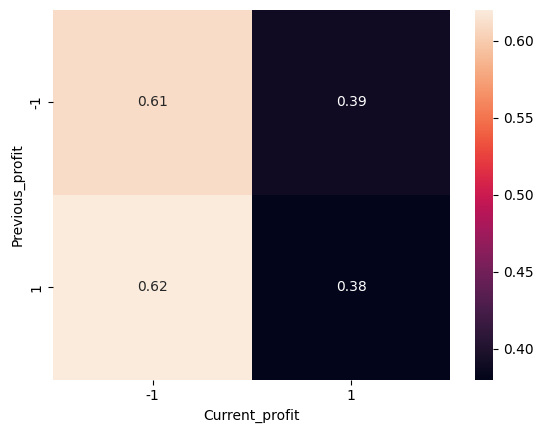

In [298]:
fin_current = np.where(np.array(fin)[1:] > 0, 1, -1)

fin_previous = np.where(np.array(fin.shift(1))[1:] > 0, 1, -1)

Crosstable = np.round(pd.crosstab(columns=fin_current, index=fin_previous, normalize='index'), 2)
Crosstable
sns.heatmap(Crosstable, annot=True)
plt.xlabel('Current_profit')
plt.ylabel('Previous_profit');

In [ ]:
std_fin = np.std(np.array(fin))
print(std_fin)
cond_list = [0.01]
fin_group = np.select(fin)

0.07434177988095807
